In [67]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
# --- CONFIGURE THIS ---
input_csv_folder = r"C:\Users\chris\Desktop\University\Thesis\PipelineResults\10_patients_GM_tiles"
# ----------------------

csv_files = glob.glob(os.path.join(input_csv_folder, "pipeline_run_*.csv"))

dfs = []
for path in csv_files:
    temp_df = pd.read_csv(path)
    temp_df = temp_df.rename(columns={"scan_folder": "scan_name"})
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

features = [
    "skeleton_length",
    "num_junctions",
    "num_components",
    "num_end_nodes",
    "num_start_nodes",
    "total_nodes",
    "end_to_start_ratio",
    "soma_area",
    "soma_perimeter",
    "soma_circularity",
    "cell_area",
    "cell_perimeter",
    "cell_convex_hull_area",
    "cell_convex_hull_perimeter",
    "cell_solidity",
    "cell_convexity",
    "cell_circularity",
    "cell_convex_circularity",
    "branch_area",
    "branch_perimeter",
    "sholl_min_radius",
    "sholl_peak_radius",
    "sholl_max_radius",
    "sholl_peak",
    "sholl_sum",
]

print(f"Number of cells in analysis {len(df)}")

Number of cells in analysis 156589


Remove Outliers based on cell_area

In [69]:
lower = df["cell_area"].quantile(0.002)
upper = df["cell_area"].quantile(0.998)

df = df[
    (df["cell_area"] >= lower) &
    (df["cell_area"] <= upper)
].copy()

print(f"Removed very small or very large cells")

print(f"Number of cells in analysis {len(df)}")

Removed very small or very large cells
Number of cells in analysis 155963


Remove cells that touch the image border (not fully contained in the tile)

In [70]:
# Tiles are 512x512 pixels.
# A cell whose bounding box touches any edge of the tile was clipped and
# therefore not fully visible. We remove any cell where:
#   xmin == 0  (touches left edge)
#   ymin == 0  (touches top edge)
#   xmax >= TILE_SIZE - 1  (touches right edge)
#   ymax >= TILE_SIZE - 1  (touches bottom edge)

TILE_SIZE = 512

before = len(df)

df = df[
    (df["xmin"] > 0 + 1) &
    (df["ymin"] > 0 + 1) &
    (df["xmax"] < TILE_SIZE - 1) &
    (df["ymax"] < TILE_SIZE - 1)
].copy()

print(f"Removed {before - len(df)} border-clipped cells ({before} -> {len(df)})")


# 117162

Removed 49226 border-clipped cells (155963 -> 106737)


Basic Clustering

In [71]:
from scipy.spatial.distance import cdist

def show_cluster_representatives(
    df_source,
    cluster_col,
    X_feature,
    title_prefix,
    idx_array=None,
    cluster_labels_array=None,
):
    """
    Display the N most-central representative cells for each cluster.

    Parameters
    ----------
    df_source : pd.DataFrame
        DataFrame whose index aligns with X_scaled (or a subsampled slice of it).
        Must have been filtered/cleaned the same way as X_scaled.
    cluster_col : str
        Name of the column in df_source that holds cluster labels.
        Pass None when cluster_labels_array is provided instead.
    X_feature : np.ndarray, shape (n_samples, n_dims)
        The coordinate space used to compute distances to the centroid
        (e.g. X_scaled for KMeans, X_tsne_fast for t-SNE, X_phate for PHATE).
    title_prefix : str
        Prefix used in the figure suptitle, e.g. 'Cluster', 't-SNE Cluster'.
    idx_array : array-like or None
        When the method used a subsample, pass the index array (e.g. tsne_idx,
        phate_idx) so we can build the correct sub-dataframe from df_clustered.
        Pass None if df_source already covers the full dataset (KMeans case).
    cluster_labels_array : array-like or None
        When cluster labels are not yet a column in df_source, pass the label
        array here and it will be added as cluster_col.
    """
    # If a subsample index is given, build the aligned sub-dataframe
    if idx_array is not None:
        df_index_array = df_clustered.index.to_numpy()
        sampled_df_index = df_index_array[idx_array]
        working_df = df_clustered.loc[sampled_df_index].copy()
    else:
        working_df = df_source.copy()

    # Attach cluster labels if not already present
    if cluster_labels_array is not None:
        working_df[cluster_col] = cluster_labels_array

    for cluster_id in sorted(working_df[cluster_col].unique()):
        cluster_mask = working_df[cluster_col] == cluster_id
        cluster_df = working_df[cluster_mask]

        # Feature vectors for this cluster (in the chosen coordinate space)
        X_cluster = X_feature[cluster_mask.values]

        # Centroid and distances
        centroid = X_cluster.mean(axis=0, keepdims=True)
        distances = cdist(X_cluster, centroid, metric='euclidean').flatten()

        # N closest cells
        closest_idxs = np.argsort(distances)[:N_REPRESENTATIVES]

        # Build representative metadata
        reps = []
        for idx in closest_idxs:
            global_index = cluster_df.iloc[idx].name
            reps.append({
                'global_cell_id': df.loc[global_index, 'global_cell_id'],
                'distance_to_centroid': distances[idx],
                'scan_name': df.loc[global_index, 'scan_name'],
                'image_name': df.loc[global_index, 'image_name'],
                'xmin': df.loc[global_index, 'xmin'],
                'ymin': df.loc[global_index, 'ymin'],
                'xmax': df.loc[global_index, 'xmax'],
                'ymax': df.loc[global_index, 'ymax'],
            })

        # Plot all N representatives side-by-side
        n = len(reps)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
        if n == 1:
            axes = [axes]
        fig.suptitle(f"{title_prefix} {cluster_id} \u2013 {n} most central cells", fontsize=14)

        for ax, r in zip(axes, reps):
            image_path = os.path.join(scan_data_root, r['scan_name'], r['image_name'] + '.jpg')
            image = cv2.imread(image_path)
            if image is None:
                ax.set_title(f"NOT FOUND\n{r['image_name']}")
                ax.axis('off')
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            x_min, y_min, x_max, y_max = int(r['xmin']), int(r['ymin']), int(r['xmax']), int(r['ymax'])
            cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
            ax.imshow(image_rgb)
            ax.axis('off')
            ax.set_title(
                f"{r['global_cell_id']}\nd={r['distance_to_centroid']:.3f}",
                fontsize=7
            )

        plt.tight_layout()
        plt.show()


In [72]:
# --- CONFIGURE THIS ---
scan_data_root = r"C:\Users\chris\Desktop\University\Thesis\ScanData\10_patients_GM_tiles"
N_REPRESENTATIVES = 4  # number of most-central cells to show per cluster
# ----------------------

## Feature Scaling & PCA

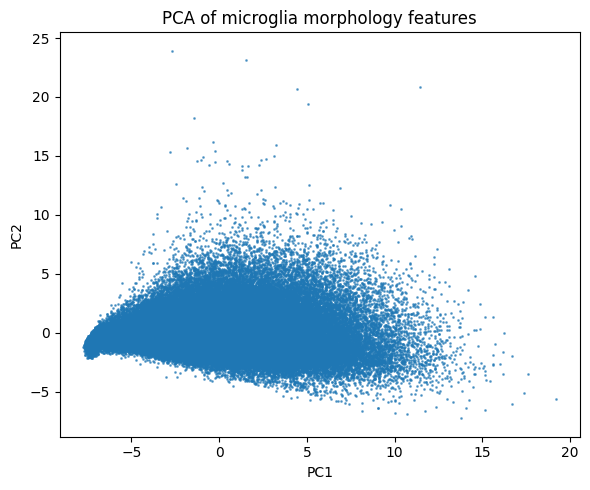

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features].dropna()

# Save the fitted scaler so labelled data can be projected into the same space
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of microglia morphology features")
plt.tight_layout()
plt.show()


## Trustworthiness & Continuity helpers

In [74]:
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors

def continuity(X_high, X_low, n_neighbors=10):
    """
    Continuity: how well true high-dim neighbours are preserved in the
    low-dim embedding.  Range 0 (worst) to 1 (perfect).
    """
    n = X_high.shape[0]
    nbrs_high = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X_high)
    _, ind_high = nbrs_high.kneighbors(X_high)
    ind_high = ind_high[:, 1:]
    nbrs_low = NearestNeighbors(n_neighbors=n).fit(X_low)
    _, ind_low_full = nbrs_low.kneighbors(X_low)
    rank_low = np.empty((n, n), dtype=int)
    for i in range(n):
        rank_low[i, ind_low_full[i]] = np.arange(n)
    penalty = 0
    for i in range(n):
        for j in ind_high[i]:
            r = rank_low[i, j]
            if r > n_neighbors:
                penalty += r - n_neighbors
    normaliser = n_neighbors * n * (2 * n - 3 * n_neighbors - 1) / 2
    return 1 - penalty / normaliser


# --- CONFIGURE THIS ---
TC_SUBSAMPLE = 10000   # number of points (full dataset is too slow)
TC_N_NEIGHBORS = 10
# ----------------------


## KMeans Clustering (for representative display)

In [75]:
from sklearn.cluster import KMeans

# KMeans on full scaled feature space (used for representative display)
clusterer = KMeans(n_clusters=4, n_init=50, random_state=42)
cluster_labels = clusterer.fit_predict(X_scaled)
df_clustered = df.loc[X.index].copy()
df_clustered["cluster"] = cluster_labels
print(f"KMeans done – {len(df_clustered):,} cells in 4 clusters")


KMeans done – 106,737 cells in 4 clusters


## t-SNE Embedding

In [ ]:
import time
from openTSNE import TSNE as openTSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# openTSNE -- much faster than sklearn on large data (FFT-accelerated Barnes-Hut)
# pip install openTSNE

# --- CONFIGURE THIS ---
TSNE_SUBSAMPLE = 60000  # keep the same as the sklearn cell for a fair comparison
TSNE_K_RANGE = range(2, 5)
# ----------------------

if TSNE_SUBSAMPLE is not None and TSNE_SUBSAMPLE < len(X_scaled):
    rng = np.random.default_rng(42)
    tsne_fast_idx = rng.choice(len(X_scaled), size=TSNE_SUBSAMPLE, replace=False)
    X_tsne_fast_input = X_scaled[tsne_fast_idx]
else:
    tsne_fast_idx = np.arange(len(X_scaled))
    X_tsne_fast_input = X_scaled

t0 = time.perf_counter()
tsne_fast = openTSNE(
    n_components=2,
    perplexity=30,
    negative_gradient_method='fft',  # FFT-accelerated, much faster than exact/bh
    n_jobs=6,                        # use all CPU cores
    random_state=42,
)
tsne_embedding = tsne_fast.fit(X_tsne_fast_input)  # TSNEEmbedding – has .transform()
X_tsne_fast = np.array(tsne_embedding)
fast_time = time.perf_counter() - t0
print(f'openTSNE runtime: {fast_time:.2f}s')

# --- Trustworthiness & Continuity (uses the same TC_SUBSAMPLE / TC_N_NEIGHBORS
#     defined in the PCA T&C cell; re-index into the tsne subsample) ---
tsne_tc_size = min(TC_SUBSAMPLE, len(X_tsne_fast_input))
rng_tsne_tc = np.random.default_rng(0)
tsne_tc_local_idx = rng_tsne_tc.choice(len(X_tsne_fast_input), size=tsne_tc_size, replace=False)
tw_tsne = trustworthiness(X_tsne_fast_input[tsne_tc_local_idx], X_tsne_fast[tsne_tc_local_idx], n_neighbors=TC_N_NEIGHBORS)
ct_tsne = continuity(X_tsne_fast_input[tsne_tc_local_idx], X_tsne_fast[tsne_tc_local_idx], n_neighbors=TC_N_NEIGHBORS)
f1_tsne = 2 * tw_tsne * ct_tsne / (tw_tsne + ct_tsne)
print(f't-SNE  |  Trustworthiness: {tw_tsne:.4f}  |  Continuity: {ct_tsne:.4f}  |  F1_TC: {f1_tsne:.4f}  (k={TC_N_NEIGHBORS}, n={tsne_tc_size})')

# Pick k with the highest silhouette score
tsne_fast_sil_scores = {}
for k in TSNE_K_RANGE:
    labels = KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(X_tsne_fast)
    tsne_fast_sil_scores[k] = silhouette_score(X_tsne_fast, labels)
    print(f'  k={k}  silhouette={tsne_fast_sil_scores[k]:.4f}')

tsne_fast_best_k = max(tsne_fast_sil_scores, key=tsne_fast_sil_scores.get)
print(f'\nBest k for openTSNE: {tsne_fast_best_k} (silhouette={tsne_fast_sil_scores[tsne_fast_best_k]:.4f})')

tsne_fast_kmeans = KMeans(n_clusters=tsne_fast_best_k, n_init=50, random_state=42)
tsne_fast_cluster_labels = tsne_fast_kmeans.fit_predict(X_tsne_fast)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=tsne_fast_cluster_labels, cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'openTSNE (FFT) - KMeans k={tsne_fast_best_k} (best silhouette)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


C:\Users\chris\AppData\Local\Temp\ipykernel_8224\432253882.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


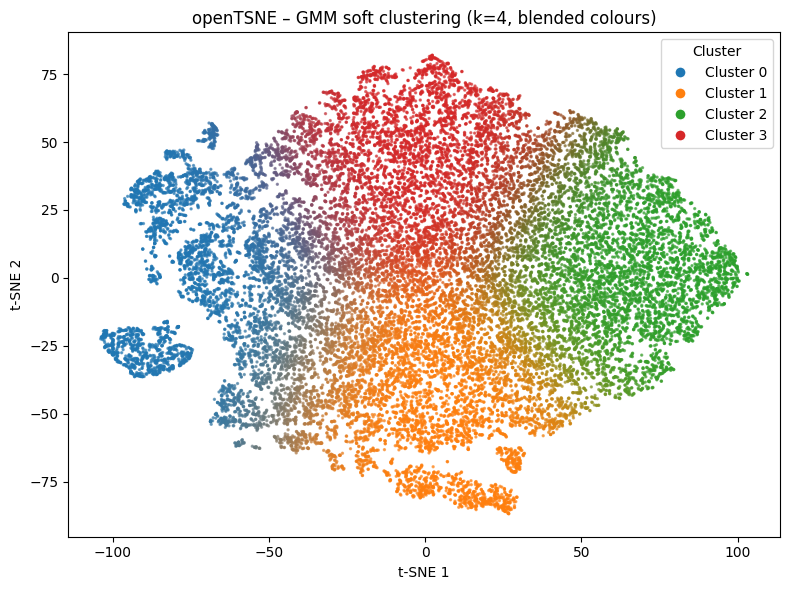

In [77]:
# --- t-SNE: GMM soft clustering (blended-colour scatter) ---
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm

# Fit GMM in the 2-D t-SNE embedding space using the same best_k as KMeans
gmm_tsne = GaussianMixture(n_components=tsne_fast_best_k, covariance_type='full', random_state=42)
gmm_tsne.fit(X_tsne_fast)
gmm_tsne_probs = gmm_tsne.predict_proba(X_tsne_fast)  # (n_samples, K)

cmap = cm.get_cmap('tab10')
base_colors = np.array([cmap(i)[:3] for i in range(tsne_fast_best_k)])
blended_colors = np.clip(gmm_tsne_probs @ base_colors, 0, 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=blended_colors, s=2, alpha=0.6)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'openTSNE – GMM soft clustering (k={tsne_fast_best_k}, blended colours)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=base_colors[i], markersize=8,
                      label=f'Cluster {i}') for i in range(tsne_fast_best_k)]
ax.legend(handles=handles, title='Cluster', loc='best')
plt.tight_layout()
plt.show()


C:\Users\chris\AppData\Local\Temp\ipykernel_8224\905816273.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


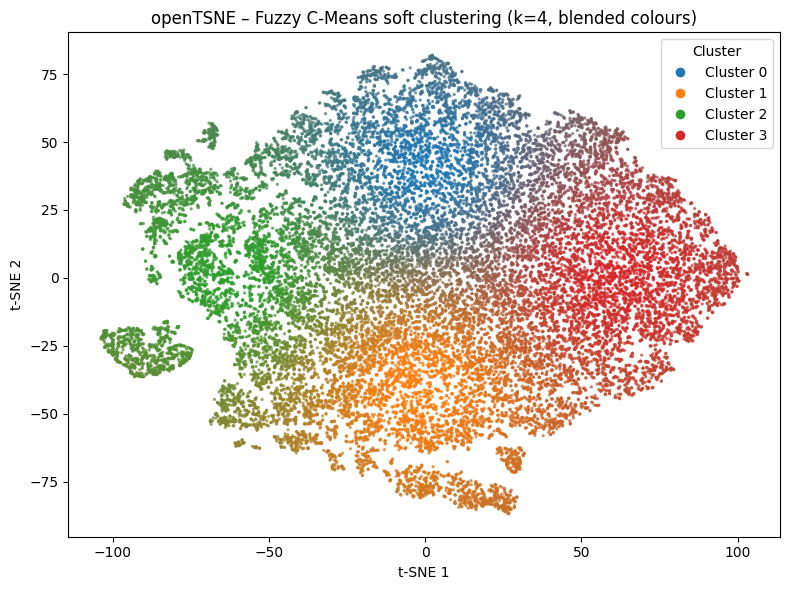

In [78]:
# --- t-SNE: Fuzzy C-Means soft clustering (blended-colour scatter) ---
from fcmeans import FCM
import matplotlib.cm as cm

fcm_tsne = FCM(n_clusters=tsne_fast_best_k, m=2.0, max_iter=1000, error=0.005, random_state=42)
fcm_tsne.fit(X_tsne_fast)
# fcm_tsne.u shape: (n_samples, K)
fcm_tsne_probs = fcm_tsne.u

cmap = cm.get_cmap('tab10')
base_colors = np.array([cmap(i)[:3] for i in range(tsne_fast_best_k)])
blended_colors = np.clip(fcm_tsne_probs @ base_colors, 0, 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=blended_colors, s=2, alpha=0.6)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'openTSNE – Fuzzy C-Means soft clustering (k={tsne_fast_best_k}, blended colours)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=base_colors[i], markersize=8,
                      label=f'Cluster {i}') for i in range(tsne_fast_best_k)]
ax.legend(handles=handles, title='Cluster', loc='best')
plt.tight_layout()
plt.show()


## Active Learning – YOLO Labelled Dataset Integration

In [99]:
# =====================================================================
# ACTIVE LEARNING – configuration
# =====================================================================

# Path to the CSV produced by initial_pipeline/process_yolo_dataset.py
LABELLED_CSV = r"C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\morphology\morphology_outputs\yolo_labelled_dataset.csv"


# Where to save the ranked selection
AL_OUTPUT_CSV = (
    r"C:\Users\chris\Desktop\University\Thesis"
    r"\AutomaticMicrogliaMorphologyAnalysis"
    r"\initial_pipeline\morphology\morphology_outputs"
    r"\active_learning_top1000.csv"
)

N_ACTIVE_LEARNING = 500  # number of candidates to select


In [100]:

# ACTIVE LEARNING – load labelled YOLO dataset & scale features

df_lab = pd.read_csv(LABELLED_CSV)
print(f"Loaded {len(df_lab):,} labelled cells from YOLO dataset")


# --- Scale with the SAME StandardScaler fitted on the unlabelled data ---
X_lab_raw = df_lab[features].dropna()
df_lab = df_lab.loc[X_lab_raw.index].copy()  # keep only rows with full features
X_lab_scaled = scaler.transform(X_lab_raw)    # transform only, do NOT re-fit
print(f"Labelled feature matrix shape: {X_lab_scaled.shape}")


Loaded 4,455 labelled cells from YOLO dataset
Labelled feature matrix shape: (4455, 25)


Projected 4,455 labelled cells into t-SNE space


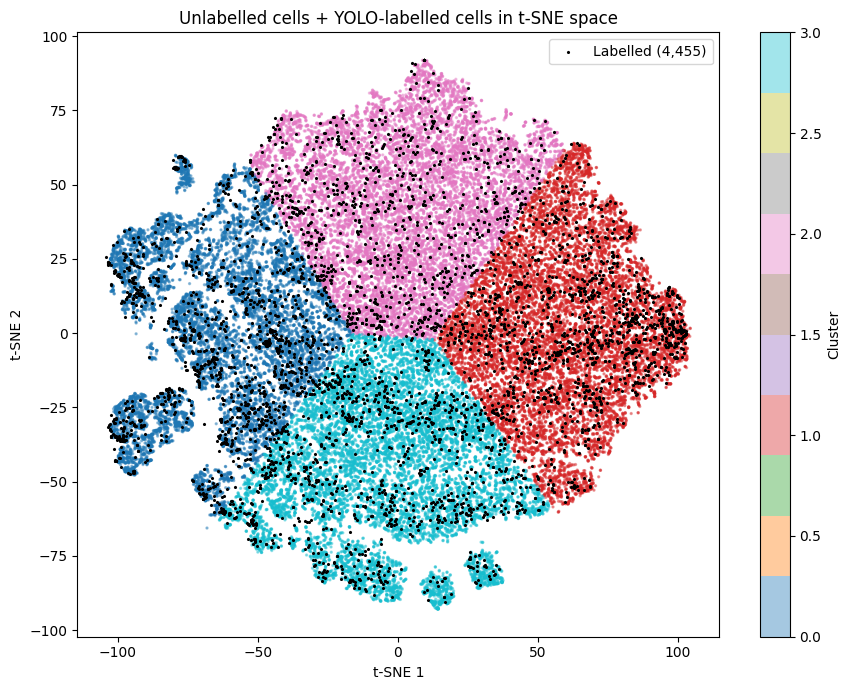

In [101]:
# openTSNE's fitted object exposes transform() which projects new points
# into the existing embedding without re-running the full optimisation.
X_lab_tsne = np.array(tsne_embedding.transform(X_lab_scaled))

print(f"Projected {len(X_lab_tsne):,} labelled cells into t-SNE space")

# --- Plot: unlabelled background + labelled overlay ---
fig, ax = plt.subplots(figsize=(9, 7))

# Background: unlabelled cells coloured by KMeans cluster
sc = ax.scatter(
    X_tsne_fast[:, 0], X_tsne_fast[:, 1],
    c=tsne_fast_cluster_labels, cmap='tab10',
    s=2, alpha=0.4, zorder=1,
)
plt.colorbar(sc, ax=ax, label='Cluster')

# Overlay: labelled cells
ax.scatter(
    X_lab_tsne[:, 0], X_lab_tsne[:, 1],
    marker='*', color='black', s=2, zorder=2,
    label=f'Labelled ({len(X_lab_tsne):,})',
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Unlabelled cells + YOLO-labelled cells in t-SNE space')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [102]:
# Strategy:
# Maintain D[i] = distance from unlabelled point i to the nearest
# known point. At each step pick argmax(D), add it to the selected set,
# and update D with the distance to that new point.

from scipy.spatial.distance import cdist
import numpy as np
import os

# NOTE:
# Here we are sampling in t-SNE space, so:
# - X_unlabelled rows correspond to positions inside X_tsne_fast
# - selected_indices will therefore be positions inside X_tsne_fast

X_unlabelled = X_tsne_fast      # shape (N_unlabelled_subsample, 2)
X_known      = X_lab_tsne       # shape (N_known, 2)

print(f"Unlabelled pool : {len(X_unlabelled):,} cells")
print(f"Known (labelled): {len(X_known):,} cells")
print(f"Selecting top-{N_ACTIVE_LEARNING} most informative unlabelled cells...")

# Compute initial D:
# for each unlabelled cell, the min distance to ANY known labelled cell
CHUNK = 1
D = np.full(len(X_unlabelled), np.inf, dtype=np.float32)

for start in range(0, len(X_known), CHUNK):
    end = min(start + CHUNK, len(X_known))
    d_chunk = cdist(X_unlabelled, X_known[start:end], metric='euclidean')
    D = np.minimum(D, d_chunk.min(axis=1))

print(f"Initial D computed. Mean min-dist = {D.mean():.4f}")
print(f"Initial D min={D.min():.4f}, max={D.max():.4f}")

# --- Greedy loop ---
selected_indices = []   # positions inside X_tsne_fast
selected_dists   = []   # D value at time of selection

for step in range(N_ACTIVE_LEARNING):
    best = int(np.argmax(D))
    best_dist = float(D[best])

    # Stop if nothing valid remains
    if not np.isfinite(best_dist):
        print(f"Stopping early at step {step}: no finite candidates left.")
        break

    selected_indices.append(best)
    selected_dists.append(best_dist)

    # Distance from every unlabelled point to the newly selected point
    d_new = np.linalg.norm(X_unlabelled - X_unlabelled[best], axis=1)

    # Keep each point's distance to its nearest covered point
    D = np.minimum(D, d_new)

    # Prevent re-selecting the same point
    D[best] = -np.inf

    if (step + 1) % 100 == 0 or step == 0:
        print(f"  step {step+1:4d} / {N_ACTIVE_LEARNING}  min_dist={best_dist:.4f}")

print(f"Greedy selection done. {len(selected_indices)} candidates chosen.")


# =====================================================================
# MAP SELECTIONS BACK TO FULL DATASET / DATAFRAME
# =====================================================================

selected_np = np.array(selected_indices, dtype=int)  # positions in X_tsne_fast

# Map subsample positions -> full X_scaled row positions
selected_full_positions = np.array(tsne_fast_idx)[selected_np]

# Map full X row positions -> df index labels
df_index_array = np.array(X.index)
selected_df_indices = df_index_array[selected_full_positions]

# Build output dataframe
df_al = df.loc[selected_df_indices, [
    'global_cell_id', 'scan_name', 'image_name',
    'xmin', 'ymin', 'xmax', 'ymax',
] + features].copy()

df_al.insert(0, 'rank', range(1, len(df_al) + 1))
df_al['min_dist_to_known'] = selected_dists
df_al['x_row_position'] = selected_full_positions

os.makedirs(os.path.dirname(AL_OUTPUT_CSV), exist_ok=True)
df_al.to_csv(AL_OUTPUT_CSV, index=False)
print(f"Saved active-learning selection -> {AL_OUTPUT_CSV}")
display(df_al.head())

Unlabelled pool : 60,000 cells
Known (labelled): 4,455 cells
Selecting top-500 most informative unlabelled cells...
Initial D computed. Mean min-dist = 1.3724
Initial D min=0.0060, max=7.9784
  step    1 / 500  min_dist=7.9784
  step  100 / 500  min_dist=3.6825
  step  200 / 500  min_dist=3.2283
  step  300 / 500  min_dist=2.9606
  step  400 / 500  min_dist=2.7514
  step  500 / 500  min_dist=2.6023
Greedy selection done. 500 candidates chosen.
Saved active-learning selection -> C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\morphology\morphology_outputs\active_learning_top1000.csv


,rank,global_cell_id,scan_name,image_name,xmin,ymin,xmax,ymax,skeleton_length,num_junctions,...,cell_convex_circularity,branch_area,branch_perimeter,sholl_min_radius,sholl_peak_radius,sholl_max_radius,sholl_peak,sholl_sum,min_dist_to_known,x_row_position
148965,1,tile_x30208_y45056_gray_matter_cell_2,2018-001_Iba1_Temporal_pole_Batch_6,tile_x30208_y45056_gray_matter,214.31259,18.345692,254.11300,57.29124,22,1,...,0.673849,64,38.970562,14,14,22,4,22,7.978414,101270
106466,2,tile_x23552_y24576_gray_matter_cell_0,2017-129_Iba1_Tp_B8_100,tile_x23552_y24576_gray_matter,198.74835,319.740480,340.61975,418.75183,159,1,...,0.754406,868,497.386864,16,80,110,14,159,7.662487,71933
155664,3,tile_x6656_y42496_gray_matter_cell_0,2018-001_Iba1_Temporal_pole_Batch_6,tile_x6656_y42496_gray_matter,108.73817,356.684500,189.70910,465.82178,115,3,...,0.804932,2351,322.149276,22,66,69,8,115,7.295618,106080
113400,4,tile_x47616_y27648_gray_matter_cell_0,2017-129_Iba1_Tp_B8_100,tile_x47616_y27648_gray_matter,196.61475,305.690300,301.73846,413.65076,96,3,...,0.759900,315,204.509666,12,14,44,6,96,6.266485,76351
10333,5,tile_x52224_y73728_gray_matter_cell_3,2014-048_Iba1_Temporal_pole_Batch_8,tile_x52224_y73728_gray_matter,226.02625,84.054910,410.46497,293.90830,353,7,...,0.832486,2823,895.577770,16,67,121,15,353,6.202779,7329


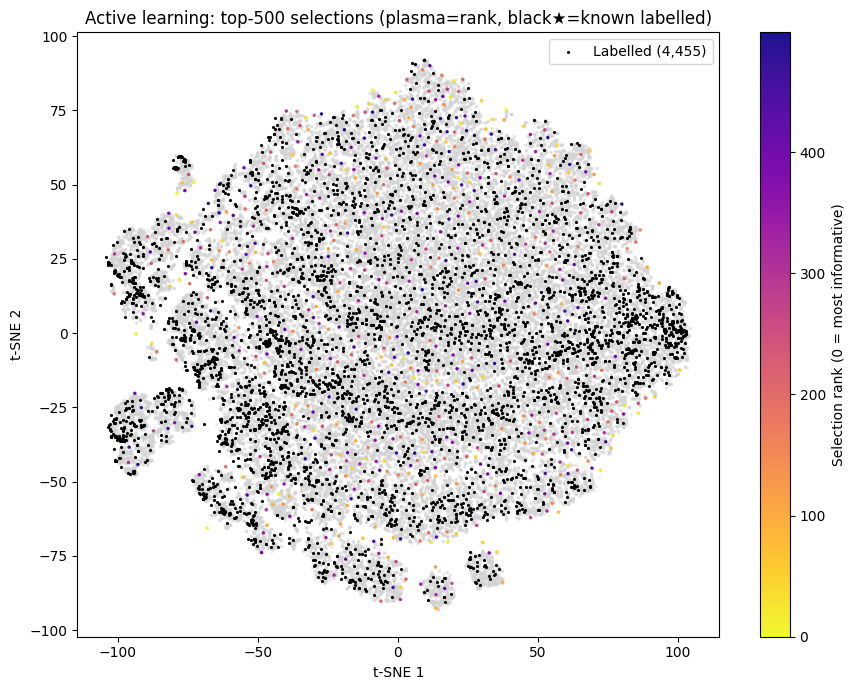

Rank 1 (most informative): global_cell_id=tile_x30208_y45056_gray_matter_cell_2
Rank 500 (least informative): global_cell_id=tile_x29696_y41984_gray_matter_cell_0


In [103]:
# Because selection was done directly on X_tsne_fast,
# the selected coordinates are simply:
sel_coords = X_tsne_fast[selected_np]

ranks = np.arange(len(selected_np))   # 0-based; rank 0 = most informative

fig, ax = plt.subplots(figsize=(9, 7))

# Background: all unlabelled cells
ax.scatter(
    X_tsne_fast[:, 0], X_tsne_fast[:, 1],
    c='lightgrey', s=2, alpha=0.3, zorder=1, rasterized=True
)

# Selected cells coloured by rank
sc2 = ax.scatter(
    sel_coords[:, 0], sel_coords[:, 1],
    c=ranks, cmap='plasma_r', s=2, zorder=2, alpha=0.95
)
plt.colorbar(sc2, ax=ax, label='Selection rank (0 = most informative)')

# Labelled cells as stars
ax.scatter(
    X_lab_tsne[:, 0], X_lab_tsne[:, 1],
    marker='*', color='black', s=2, zorder=3,
    label=f'Labelled ({len(X_lab_tsne):,})'
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(
    f'Active learning: top-{len(selected_np)} selections '
    f'(plasma=rank, black★=known labelled)'
)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Rank 1 (most informative): global_cell_id={df_al.iloc[0]['global_cell_id']}")
print(f"Rank {len(df_al)} (least informative): global_cell_id={df_al.iloc[-1]['global_cell_id']}")

## Export Ultralytics YOLO Dataset for Active Learning Round

Images that contain **at least 1** of the 1000 selected cells are included.
Every annotation from `df_lab` on those images is exported (so the YOLO
model sees the complete ground-truth for each image).

In [ ]:
import shutil
from pathlib import Path

# =====================================================================
# CONFIGURATION
# =====================================================================
# Where the new YOLO-format dataset will be written
YOLO_AL_DIR = Path(
    r"C:\Users\chris\Desktop\University\Thesis"
    r"\AutomaticMicrogliaMorphologyAnalysis"
    r"\initial_pipeline\morphology\morphology_outputs"
    r"\yolo_al_dataset"
)

TILE_SIZE = 512  # image dimensions (square tiles)
CLASS_ID = 0     # single class: cell
# =====================================================================

# ------------------------------------------------------------------
# 1. Find images that contain at least one AL-selected cell
# ------------------------------------------------------------------
al_image_names = set(df_al["image_name"].unique())
print(f"Images with ≥1 AL-selected cell: {len(al_image_names):,}")

# ------------------------------------------------------------------
# 2. Pull ALL annotations for those images from df (unlabelled pool)
#    so the user can review / fix YOLO predictions and turn them into
#    new labelled training data
# ------------------------------------------------------------------
df_export = df[df["image_name"].isin(al_image_names)].copy()
print(f"Total annotations to export: {len(df_export):,}  "
      f"across {df_export['image_name'].nunique():,} images")

# ------------------------------------------------------------------
# 3. Convert pixel boxes → YOLO normalised format
#    class_id  x_center  y_center  width  height   (all 0-1)
# ------------------------------------------------------------------
df_export["x_center"] = ((df_export["xmin"] + df_export["xmax"]) / 2.0) / TILE_SIZE
df_export["y_center"] = ((df_export["ymin"] + df_export["ymax"]) / 2.0) / TILE_SIZE
df_export["box_w"]    = (df_export["xmax"] - df_export["xmin"]) / TILE_SIZE
df_export["box_h"]    = (df_export["ymax"] - df_export["ymin"]) / TILE_SIZE

# ------------------------------------------------------------------
# 4. Create directory structure & write label files / copy images
# ------------------------------------------------------------------
img_out_dir = YOLO_AL_DIR / "images" / "train"
lbl_out_dir = YOLO_AL_DIR / "labels" / "train"
img_out_dir.mkdir(parents=True, exist_ok=True)
lbl_out_dir.mkdir(parents=True, exist_ok=True)

written_imgs = 0
skipped_imgs = 0

for image_name, grp in df_export.groupby("image_name"):
    # --- locate source image (use the first scan_name that has it) ---
    scan_name = grp["scan_name"].iloc[0]
    src_img = Path(scan_data_root) / scan_name / (image_name + ".jpg")

    if not src_img.exists():
        print(f"  [SKIP] image not found: {src_img}")
        skipped_imgs += 1
        continue

    # copy image
    dst_img = img_out_dir / (image_name + ".jpg")
    if not dst_img.exists():
        shutil.copy2(src_img, dst_img)
    written_imgs += 1

    # write label .txt
    lbl_path = lbl_out_dir / (image_name + ".txt")
    with open(lbl_path, "w") as f:
        for _, row in grp.iterrows():
            f.write(
                f"{CLASS_ID} "
                f"{row['x_center']:.6f} "
                f"{row['y_center']:.6f} "
                f"{row['box_w']:.6f} "
                f"{row['box_h']:.6f}\n"
            )

print(f"\nDone — {written_imgs} images copied, {skipped_imgs} skipped.")

# ------------------------------------------------------------------
# 5. Write ultralytics data.yaml
# ------------------------------------------------------------------
yaml_path = YOLO_AL_DIR / "data.yaml"
yaml_content = (
    f"path: {YOLO_AL_DIR.resolve()}\n"
    f"train: images/train\n"
    f"val: images/train\n"
    f"\n"
    f"names:\n"
    f"  0: microglia\n"
)
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Wrote data.yaml  -> {yaml_path}")
print(f"Dataset ready at : {YOLO_AL_DIR.resolve()}")
print(f"  images/train/  : {len(list(img_out_dir.glob('*.jpg'))):,} files")
print(f"  labels/train/  : {len(list(lbl_out_dir.glob('*.txt'))):,} files")

Images with ≥1 AL-selected cell: 487
Total annotations to export: 3,453  across 487 images

Done — 487 images copied, 0 skipped.
Wrote data.yaml  -> C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\morphology\morphology_outputs\yolo_al_dataset\data.yaml
Dataset ready at : C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\morphology\morphology_outputs\yolo_al_dataset
  images/train/  : 487 files
  labels/train/  : 487 files


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Pick one image from the export to inspect
check_image_name = list(al_image_names)[0]
print(f"Inspecting: {check_image_name}")

# --- Original annotations from df (unlabelled pipeline predictions) ---
df_orig = df[df["image_name"] == check_image_name]

# --- Ultralytics export: read back from .txt ---
lbl_path = YOLO_AL_DIR / "labels" / "train" / (check_image_name + ".txt")
yolo_boxes = []
with open(lbl_path) as f:
    for line in f:
        parts = line.strip().split()
        cls, cx, cy, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        # Convert YOLO normalised back to pixel coords
        x1 = (cx - w / 2) * TILE_SIZE
        y1 = (cy - h / 2) * TILE_SIZE
        x2 = (cx + w / 2) * TILE_SIZE
        y2 = (cy + h / 2) * TILE_SIZE
        yolo_boxes.append((cls, x1, y1, x2, y2))

print(f"  df boxes: {len(df_orig)}")
print(f"  YOLO txt boxes: {len(yolo_boxes)}")

# --- Load the image ---
scan_name = df_orig["scan_name"].iloc[0]
img_path = Path(scan_data_root) / scan_name / (check_image_name + ".jpg")
img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# LEFT: original df annotations
ax = axes[0]
ax.imshow(img_rgb)
for _, row in df_orig.iterrows():
    x1, y1, x2, y2 = row["xmin"], row["ymin"], row["xmax"], row["ymax"]
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor="lime", linewidth=1))
ax.set_title(f"Original df — {len(df_orig)} boxes")
ax.axis("off")

# RIGHT: ultralytics export (converted back to pixels)
ax = axes[1]
ax.imshow(img_rgb)
for cls, x1, y1, x2, y2 in yolo_boxes:
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor="red", linewidth=1))
ax.set_title(f"YOLO export — {len(yolo_boxes)} boxes")
ax.axis("off")

fig.suptitle(f"Annotation comparison: {check_image_name}", fontsize=13)
plt.tight_layout()
plt.show()

# Print a few rows side-by-side so you can spot rounding issues
print("\nFirst 5 df boxes (xmin, ymin, xmax, ymax):")
for _, row in df_orig.head(5).iterrows():
    print(f"  ({row['xmin']:.4f}, {row['ymin']:.4f}, {row['xmax']:.4f}, {row['ymax']:.4f})")

print("\nFirst 5 YOLO boxes reconverted to pixels (x1, y1, x2, y2):")
for cls, x1, y1, x2, y2 in yolo_boxes[:5]:
    print(f"  ({x1:.4f}, {y1:.4f}, {x2:.4f}, {y2:.4f})")